# Imports

In [1]:
from random import random
from data_loader import load_conll2003
from preprocessing import build_vocab, tokenize
from model import SkipGramNS
from trainer import train_skipgram
from utils import word_analogy, save_embeddings, most_similar
from dataset import get_negative_samples, create_skipgram_pairs

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)
print("All modules imported successfully.")

[nltk_data] Downloading package stopwords to /home/amr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/amr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All modules imported successfully.


# Load dataset

In [2]:
print("Loading CoNLL2003 dataset...")

sentences = load_conll2003()

print("Dataset loaded successfully.")
print("Total number of sentences:", len(sentences))

print("\nExample sentence:")
print(sentences[0])

Loading CoNLL2003 dataset...


Dataset loaded successfully.
Total number of sentences: 20744

Example sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


# Build vocab

In [3]:
print("Building vocabulary...")

# Tokenize sentences into words (handle punctuation and case)
tokenized = tokenize(sentences)

# Build vocabulary
vocab, idx_to_word = build_vocab(tokenized)
V = len(vocab)

print("Vocabulary size:", V)

print("\nExample word to index mapping:")
for word in list(vocab.keys())[:10]:
    print(f"{word}: {vocab[word]}")

Building vocabulary...
Vocabulary size: 5123

Example word to index mapping:
eu: 0
reject: 1
german: 2
call: 3
boycott: 4
british: 5
peter: 6
blackburn: 7
brussels: 8
european: 9


# Create dataset

In [4]:
print("Creating Skip-Gram dataset...")

window_size = 2
pairs = create_skipgram_pairs(tokenized, vocab, window_size)
print("Number of training pairs:", len(pairs))

for i in range(10):
    target, context = pairs[i]
    print(
        idx_to_word[target],
        "->",
        idx_to_word[context]
    )

Creating Skip-Gram dataset...
Number of training pairs: 389038
eu -> reject
eu -> german
reject -> eu
reject -> german
reject -> call
german -> eu
german -> reject
german -> call
german -> boycott
call -> reject


# Create model

In [5]:
embedding_dim = 100

print("Initializing Word2Vec SGNS model...")

model = SkipGramNS(vocab_size=V, embedding_dim=embedding_dim)

print("Model initialized successfully.")
print("Shape of target embeddings:", model.W_out.shape)
print("Shape of context embeddings:", model.W_in.shape)

Initializing Word2Vec SGNS model...
Model initialized successfully.
Shape of target embeddings: (5123, 100)
Shape of context embeddings: (5123, 100)


# Train model

In [6]:
# Train
epochs = 50
loss_history = train_skipgram(
    pairs=pairs,
    vocab=vocab,
    model=model,
    window_size=2,
    neg_samples=5,
    lr=0.01,
    epochs=epochs
)
print("Training finished.")

Epoch 1, Loss: 4.1529
Epoch 2, Loss: 3.5200
Epoch 3, Loss: 2.5176
Epoch 4, Loss: 2.2466
Epoch 5, Loss: 2.1518
Epoch 6, Loss: 2.0982
Epoch 7, Loss: 2.0563
Epoch 8, Loss: 2.0166
Epoch 9, Loss: 1.9793
Epoch 10, Loss: 1.9420
Epoch 11, Loss: 1.9042
Epoch 12, Loss: 1.8661
Epoch 13, Loss: 1.8297
Epoch 14, Loss: 1.7919
Epoch 15, Loss: 1.7564
Epoch 16, Loss: 1.7190
Epoch 17, Loss: 1.6845
Epoch 18, Loss: 1.6464
Epoch 19, Loss: 1.6111
Epoch 20, Loss: 1.5764
Epoch 21, Loss: 1.5399
Epoch 22, Loss: 1.5067
Epoch 23, Loss: 1.4752
Epoch 24, Loss: 1.4393
Epoch 25, Loss: 1.4073
Epoch 26, Loss: 1.3781
Epoch 27, Loss: 1.3459
Epoch 28, Loss: 1.3170
Epoch 29, Loss: 1.2887
Epoch 30, Loss: 1.2616
Epoch 31, Loss: 1.2360
Epoch 32, Loss: 1.2120
Epoch 33, Loss: 1.1880
Epoch 34, Loss: 1.1647
Epoch 35, Loss: 1.1417
Epoch 36, Loss: 1.1207
Epoch 37, Loss: 1.1016
Epoch 38, Loss: 1.0790
Epoch 39, Loss: 1.0627
Epoch 40, Loss: 1.0459
Epoch 41, Loss: 1.0293
Epoch 42, Loss: 1.0105
Epoch 43, Loss: 0.9976
Epoch 44, Loss: 0.98

# Plot 

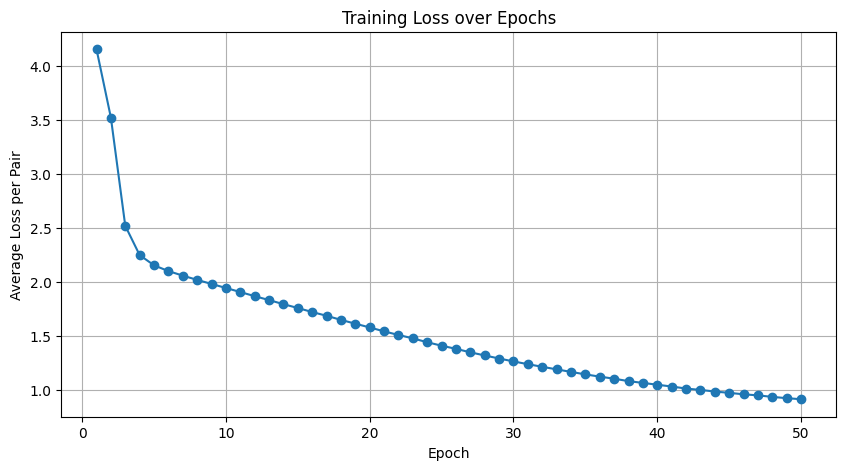

In [7]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Pair")  # changed from Total Loss
plt.grid(True)
plt.show()

# Similarity Test

In [8]:
W_in_norm = model.W_in / (np.linalg.norm(model.W_in, axis=1, keepdims=True) + 1e-9)

# Most similar to 'match'
print("\nMost similar words to 'match':")
results = most_similar("match", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'tournament'
print("\nMost similar words to 'tournament':")
results = most_similar("tournament", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'percent'
print("\nMost similar words to 'percent':")
results = most_similar("percent", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'year'
print("\nMost similar words to 'germany':")
results = most_similar("germany", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")


Most similar words to 'match':
1. xi -> 0.5560
2. pretty -> 0.5113
3. trent -> 0.5106
4. sidhu -> 0.5098
5. tasmania -> 0.5054

Most similar words to 'tournament':
1. toshiba -> 0.6770
2. hamlet -> 0.6714
3. prefix -> 0.6700
4. trofej -> 0.6552
5. badminton -> 0.6549

Most similar words to 'percent':
1. minus -> 0.6518
2. trillion -> 0.5446
3. seasonally -> 0.5376
4. turnover -> 0.5364
5. adjusted -> 0.5346

Most similar words to 'germany':
1. gerg -> 0.7634
2. teutenberg -> 0.7575
3. hilde -> 0.7570
4. seizinger -> 0.7349
5. katja -> 0.6786


# Save Embeddings

In [9]:
embeddings_file = "embeddings.txt"
save_embeddings(model.W_in, idx_to_word, embeddings_file)
print(f"Embeddings saved to {embeddings_file}")

Embeddings saved to embeddings.txt


# Word Analogy

In [10]:
# Analogy: badminton : badminton :: football : ?
result = word_analogy("badminton", "badminton", "football", W_in_norm, vocab, idx_to_word, topk=3)

print("Analogy: 'badminton' is to 'badminton' as 'football' is to ?")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Analogy: brussels : belgium :: berlin : ?
result = word_analogy("brussels", "belgium", "berlin", W_in_norm, vocab, idx_to_word, topk=3)
print("\nAnalogy: 'brussels' is to 'belgium' as 'berlin' is to ?")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word} -> {score:.4f}")

Analogy: 'badminton' is to 'badminton' as 'football' is to ?
1. nhl -> 0.5733
2. goalscorers -> 0.5665
3. coaching -> 0.5642

Analogy: 'brussels' is to 'belgium' as 'berlin' is to ?
1. capiot -> 0.5181
2. sex -> 0.5072
3. paedophile -> 0.4920
